In [65]:
import ast
import re
from pathlib import Path

import pandas as pd

# -----------------------------
# CONFIG
# -----------------------------
TRIALS_CSV = Path("trials.csv")

# folder with many per-session csvs like "11-6-25_session.csv"
ALIGNED_DIR = Path("aligned_sessions_with_rois")
ALIGNED_GLOB = "*_session.csv"

FRAME_COL = "beh_frame_idx"
X_COL = "ear_mid_x"
Y_COL = "ear_mid_y"
VIDEO_COL = "beh_vid_path"

# -----------------------------
# Helpers
# -----------------------------
def canon_sid(s: str) -> str:
    """Normalize IDs: '11-6-25' or '11/6/25' -> '11/6/25'."""
    s = str(s).strip()
    parts = re.split(r"[-_/]", s)
    if len(parts) == 3 and all(p.isdigit() for p in parts):
        m, d, y = parts
        return f"{int(m)}/{int(d)}/{y}"
    return s

def sid_from_session_filename(p: Path) -> str:
    """'11-6-25_session.csv' -> '11/6/25'."""
    stem = p.stem.replace("_session", "")
    return canon_sid(stem)

def parse_pair_cell(v):
    """Parse '(a,b)' or '[a,b]' or 'a,b' -> (a,b)."""
    if pd.isna(v):
        return None
    s = str(v).strip()
    try:
        obj = ast.literal_eval(s)
        if isinstance(obj, (tuple, list)) and len(obj) == 2:
            return (int(obj[0]), int(obj[1]))
    except Exception:
        pass
    parts = [p.strip() for p in s.replace("(", "").replace(")", "").split(",")]
    if len(parts) == 2:
        return (int(float(parts[0])), int(float(parts[1])))
    return None

# -----------------------------
# 1) Load trials_wide.csv -> trials_by_session
# -----------------------------
trials_df = pd.read_csv(TRIALS_CSV)

trials_by_session = {}
for col in trials_df.columns:
    sid = canon_sid(col)
    pairs = []
    for v in trials_df[col].dropna().tolist():
        pair = parse_pair_cell(v)
        if pair is not None:
            pairs.append(pair)
    if pairs:
        trials_by_session[sid] = pairs

if not trials_by_session:
    raise ValueError("No trials parsed from trials_wide.csv. Check cell formatting like '(start,end)'.")

# -----------------------------
# 2) Load ALL per-session aligned CSVs -> aligned_sessions_with_rois
# -----------------------------
aligned_sessions_with_rois = {}
for p in sorted(ALIGNED_DIR.glob(ALIGNED_GLOB)):
    sid = sid_from_session_filename(p)
    df = pd.read_csv(p)

    # required columns check
    required_cols = {FRAME_COL, X_COL, Y_COL, VIDEO_COL}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{p.name} missing columns {missing}. Found: {list(df.columns)}")

    df = df.sort_values(FRAME_COL).reset_index(drop=True)
    aligned_sessions_with_rois[sid] = df

if not aligned_sessions_with_rois:
    raise ValueError(f"No aligned session CSVs found in {ALIGNED_DIR} matching {ALIGNED_GLOB}")

# -----------------------------
# 3) Keep only overlapping sessions
# -----------------------------
common_sessions = sorted(set(trials_by_session) & set(aligned_sessions_with_rois))
if not common_sessions:
    raise ValueError(
        "No overlapping session IDs between trials_wide.csv columns and session CSV filenames.\n"
        f"Trials keys example: {list(trials_by_session.keys())[:10]}\n"
        f"Session keys example: {list(aligned_sessions_with_rois.keys())[:10]}"
    )

trials_by_session = {k: trials_by_session[k] for k in common_sessions}
aligned_sessions_with_rois = {k: aligned_sessions_with_rois[k] for k in common_sessions}

print("Loaded sessions:", len(common_sessions))
print("Example session IDs:", common_sessions)

Loaded sessions: 7
Example session IDs: ['11/13/25', '11/14/25', '11/18/25', '11/20/25', '11/21/25', '11/25/25', '11/6/25']


In [66]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import cv2

# -----------------------------
# GUI CONFIG
# -----------------------------
ARENA_ALPHA = 0.6
INVERT_Y = True

LABELS = [
    "left_small_loop",
    "left_inverse_small_loop",
    "left_big_loop",
    "right_small_loop",
    "right_inverse_small_loop",
    "right_big_loop",
    "non_characteristic",
]

arena_frame_cache = {}
labels_records = []

def get_arena_frame(session_id: str):
    if session_id in arena_frame_cache:
        return arena_frame_cache[session_id]

    df = aligned_sessions_with_rois[session_id]
    video_path = df[VIDEO_COL].iloc[0]

    cap = cv2.VideoCapture(str(video_path))
    ret, frame = cap.read()
    cap.release()

    if not ret or frame is None:
        raise RuntimeError(f"Could not read first frame from video: {video_path}")

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    arena_frame_cache[session_id] = frame
    return frame

def get_trial_df(session_id: str, trial_idx: int):
    s, e = trials_by_session[session_id][trial_idx]
    df = aligned_sessions_with_rois[session_id]
    df_trial = df[(df[FRAME_COL] >= int(s)) & (df[FRAME_COL] <= int(e))].copy()
    return df_trial, int(s), int(e)

def plot_trial_trajectory(df_trial, session_id=None, s=None, e=None):
    x = df_trial[X_COL].to_numpy(dtype=float)
    y = df_trial[Y_COL].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    fig, ax = plt.subplots(figsize=(6, 6))

    arena_img = get_arena_frame(session_id)
    h, w = arena_img.shape[:2]
    ax.imshow(arena_img, extent=[0, w, h, 0], interpolation="nearest", alpha=ARENA_ALPHA)

    if len(x) > 1:
        t = np.linspace(0, 1, len(x))
        ax.scatter(x, y, c=t, s=6)
        ax.plot(x, y, alpha=0.3)
    else:
        ax.plot(x, y)

    if len(x) > 0:
        ax.scatter([x[0]], [y[0]], marker="o", s=60, label="start")
        ax.scatter([x[-1]], [y[-1]], marker="x", s=60, label="end")

    ax.set_title(f"Session {session_id} | Frames {s}–{e} | N={len(x)}")
    ax.set_aspect("equal", adjustable="box")
    if INVERT_Y:
        ax.invert_yaxis()

    ax.legend(loc="best")
    ax.grid(True)
    plt.show()

# -----------------------------
# Widgets
# -----------------------------
session_ids = sorted(list(trials_by_session.keys()))
session_dropdown = widgets.Dropdown(options=session_ids, value=session_ids[0], description="Session:")

trial_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(trials_by_session[session_dropdown.value]) - 1,
    step=1,
    description="Trial:",
    continuous_update=False
)

label_dropdown = widgets.Dropdown(options=LABELS, value=LABELS[0], description="Label:")
notes_text = widgets.Text(value="", description="Notes:", placeholder="optional")

save_button = widgets.Button(description="Save label", button_style="success")
skip_button = widgets.Button(description="Skip", button_style="warning")
undo_button = widgets.Button(description="Undo last", button_style="danger")
export_button = widgets.Button(description="Export CSV", button_style="info")

status_out = widgets.Output()
plot_out = widgets.Output()

def refresh_trial(change=None):
    with plot_out:
        clear_output(wait=True)
        sid = session_dropdown.value
        ti = int(trial_slider.value)
        df_trial, s, e = get_trial_df(sid, ti)
        plot_trial_trajectory(df_trial, session_id=sid, s=s, e=e)

    with status_out:
        clear_output(wait=True)
        print(f"Ready: session={sid}, trial={ti}")
        if df_trial.empty:
            print("WARNING: empty slice")
        else:
            print(f"Frames in slice: {df_trial[FRAME_COL].min()}–{df_trial[FRAME_COL].max()} (expected {s}–{e})")

def update_slider_range(change):
    sid = change["new"]
    trial_slider.max = len(trials_by_session[sid]) - 1
    trial_slider.value = 0
    refresh_trial()

def save_label(_):
    sid = session_dropdown.value
    ti = int(trial_slider.value)
    s, e = trials_by_session[sid][ti]

    rec = dict(
        session_id=sid,
        trial_idx=ti,
        start_frame=int(s),
        end_frame=int(e),
        label=str(label_dropdown.value),
        notes=str(notes_text.value),
    )
    labels_records.append(rec)

    with status_out:
        clear_output(wait=True)
        print(f"Saved: {rec}")
        print(f"Total labeled: {len(labels_records)}")

    if trial_slider.value < trial_slider.max:
        trial_slider.value += 1

def skip_trial(_):
    if trial_slider.value < trial_slider.max:
        trial_slider.value += 1

def undo_last(_):
    with status_out:
        clear_output(wait=True)
        if labels_records:
            removed = labels_records.pop()
            print("Removed:", removed)
        else:
            print("Nothing to undo.")

def export_labels(_):
    if not labels_records:
        with status_out:
            clear_output(wait=True)
            print("No labels to export yet.")
        return
    df_labels = pd.DataFrame(labels_records)
    df_labels.to_csv("trajectory_trial_labels.csv", index=False)
    with status_out:
        clear_output(wait=True)
        print("Exported trajectory_trial_labels.csv")
        display(df_labels.tail(10))

session_dropdown.observe(update_slider_range, names="value")
trial_slider.observe(refresh_trial, names="value")
save_button.on_click(save_label)
skip_button.on_click(skip_trial)
undo_button.on_click(undo_last)
export_button.on_click(export_labels)

display(
    widgets.HBox([session_dropdown, trial_slider]),
    widgets.HBox([label_dropdown, notes_text]),
    widgets.HBox([save_button, skip_button, undo_button, export_button]),
    plot_out,
    status_out
)

refresh_trial()

Output()

Output()

In [67]:
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull


class featurizer:

    def __init__(
        self,
        ts_cols=("ear_mid_x", "ear_mid_y", "head_dir_rad",
                 "dist_to_arena_center_px", "ang_vel_rad_s"),
        T=50,
        fps=30.0,
        frame_col="beh_frame_idx",
        x_col="ear_mid_x",
        y_col="ear_mid_y",
        hd_col="head_dir_rad",
        center_col="dist_to_arena_center_px",
        ang_vel_col="ang_vel_rad_s",
        make_xy_relative=True,
        min_points_per_channel=2,
    ):

        self.ts_cols = list(ts_cols)
        self.T = int(T)
        self.fps = float(fps)

        self.frame_col = frame_col
        self.x_col = x_col
        self.y_col = y_col
        self.hd_col = hd_col
        self.center_col = center_col
        self.ang_vel_col = ang_vel_col

        self.make_xy_relative = bool(make_xy_relative)
        self.min_points_per_channel = int(min_points_per_channel)

        self._ix = self.ts_cols.index(x_col) if x_col in self.ts_cols else None
        self._iy = self.ts_cols.index(y_col) if y_col in self.ts_cols else None
        self._ihd = self.ts_cols.index(hd_col) if hd_col in self.ts_cols else None

    # ------------------------------------------------------------
    # Slice trial
    # ------------------------------------------------------------

    def slice_trial(self, df_session: pd.DataFrame, s: int, e: int):

        return df_session[
            (df_session[self.frame_col] >= int(s)) &
            (df_session[self.frame_col] <= int(e))
        ].copy()

    # ------------------------------------------------------------
    # Radius of gyration
    # ------------------------------------------------------------

    @staticmethod
    def _radius_of_gyration_xy(x, y):

        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        x, y = x[m], y[m]

        if len(x) == 0:
            return np.nan

        xc = x.mean()
        yc = y.mean()

        return float(np.sqrt(np.mean((x - xc)**2 + (y - yc)**2)))

    # ------------------------------------------------------------
    # Convex hull area
    # ------------------------------------------------------------

    @staticmethod
    def _convex_hull_area_xy(x, y):

        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        pts = np.column_stack([x[m], y[m]])

        if len(pts) < 3:
            return np.nan

        pts = np.unique(pts, axis=0)

        if len(pts) < 3:
            return np.nan

        try:
            hull = ConvexHull(pts)
            return float(hull.volume)   # area in 2D
        except Exception:
            return np.nan

    # ------------------------------------------------------------
    # Scalar trajectory features
    # ------------------------------------------------------------

    def _big_small_scalars(self, df_trial: pd.DataFrame):

        x = df_trial[self.x_col].to_numpy(dtype=float)
        y = df_trial[self.y_col].to_numpy(dtype=float)

        mxy = np.isfinite(x) & np.isfinite(y)
        x, y = x[mxy], y[mxy]

        if len(x) < 2:
            return np.full(14, np.nan, dtype=float)

        xmin = float(np.min(x))
        xmax = float(np.max(x))
        ymin = float(np.min(y))
        ymax = float(np.max(y))

        bbox_width = xmax - xmin
        bbox_height = ymax - ymin
        bbox_area = bbox_width * bbox_height
        aspect_ratio = bbox_width / (bbox_height + 1e-12)

        hull_area = self._convex_hull_area_xy(x, y)

        dx = np.diff(x)
        dy = np.diff(y)

        step = np.sqrt(dx**2 + dy**2)
        path_len = float(step.sum())

        disp = float(np.sqrt((x[-1]-x[0])**2 + (y[-1]-y[0])**2))

        straightness = disp / path_len if path_len > 1e-9 else np.nan

        rg = self._radius_of_gyration_xy(x, y)

        # center distance stats

        if self.center_col in df_trial.columns:

            r = df_trial.loc[mxy, self.center_col].to_numpy(dtype=float)
            r = r[np.isfinite(r)]

            center_mean = float(np.mean(r)) if len(r) else np.nan
            center_max = float(np.max(r)) if len(r) else np.nan

        else:

            center_mean = np.nan
            center_max = np.nan

        # angular velocity stats

        if self.ang_vel_col in df_trial.columns:

            av = df_trial[self.ang_vel_col].to_numpy(dtype=float)
            av = av[np.isfinite(av)]

            ang_vel_mean = float(np.mean(av)) if len(av) else np.nan
            ang_vel_abs_mean = float(np.mean(np.abs(av))) if len(av) else np.nan
            ang_vel_abs_max = float(np.max(np.abs(av))) if len(av) else np.nan
            ang_vel_std = float(np.std(av)) if len(av) else np.nan

        else:

            ang_vel_mean = np.nan
            ang_vel_abs_mean = np.nan
            ang_vel_abs_max = np.nan
            ang_vel_std = np.nan

        return np.array([
            rg,
            bbox_width,
            bbox_height,
            bbox_area,
            aspect_ratio,
            hull_area,
            path_len,
            straightness,
            center_mean,
            center_max,
            ang_vel_mean,
            ang_vel_abs_mean,
            ang_vel_abs_max,
            ang_vel_std
        ], dtype=float)

    # ------------------------------------------------------------
    # Interpolate channels
    # ------------------------------------------------------------

    def _interp_channel(self, vals, T, unwrap_angles=False):

        vals = np.asarray(vals, dtype=float)

        idx = np.flatnonzero(np.isfinite(vals))

        if len(idx) < self.min_points_per_channel:
            return None

        y = vals[idx]

        if unwrap_angles:
            y = np.unwrap(y)

        x_old = idx.astype(float)
        x_old = (x_old - x_old[0]) / (x_old[-1] - x_old[0] + 1e-12)

        x_new = np.linspace(0, 1, T)

        return np.interp(x_new, x_old, y)

    # ------------------------------------------------------------
    # Fixed length time series
    # ------------------------------------------------------------

    def _to_fixed_ts_allow_nans(self, df_trial):

        arr = df_trial[self.ts_cols].to_numpy(dtype=float)

        L, F = arr.shape

        out = np.empty((self.T, F), dtype=float)

        for k, col in enumerate(self.ts_cols):

            unwrap = (col == self.hd_col)

            ch = self._interp_channel(arr[:, k], self.T, unwrap_angles=unwrap)

            if ch is None:
                return None

            out[:, k] = ch

        if self.make_xy_relative and self._ix is not None and self._iy is not None:

            out[:, self._ix] -= out[0, self._ix]
            out[:, self._iy] -= out[0, self._iy]

        return out

    # ------------------------------------------------------------
    # Final feature vector
    # ------------------------------------------------------------

    def featurize(self, df_trial):

        ts = self._to_fixed_ts_allow_nans(df_trial)

        if ts is None:
            return None

        ts_vec = ts.reshape(-1)

        scalars = self._big_small_scalars(df_trial)

        return np.concatenate([ts_vec, scalars], axis=0)

In [68]:
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd

labels = pd.read_csv("trajectory_trial_labels.csv")
labels["session_id"] = labels["session_id"].astype(str)
labels["trial_idx"] = labels["trial_idx"].astype(int)
labels["start_frame"] = labels["start_frame"].astype(int)
labels["end_frame"] = labels["end_frame"].astype(int)
labels["label"] = labels["label"].astype(str)

X_list, y_list, meta = [], [], []

feat_engine = featurizer()

for r in labels.itertuples(index=False):
    sid = r.session_id
    if sid not in aligned_sessions_with_rois:
        continue

    df_session = aligned_sessions_with_rois[sid]
    df_trial = feat_engine.slice_trial(df_session, r.start_frame, r.end_frame)
    feat = feat_engine.featurize(df_trial)
    if feat is None:
        continue

    X_list.append(feat)
    y_list.append(r.label)
    meta.append((sid, int(r.trial_idx)))

X = np.vstack(X_list)
y = np.array(y_list)

Xt, Xv, yt, yv = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

print("X shape:", X.shape, "y:", y.shape)

X shape: (266, 264) y: (266,)


In [69]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report


clf_svc = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(class_weight="balanced", C=1.0, max_iter=20000))
])

clf_svc.fit(Xt, yt)
pred_svc = clf_svc.predict(Xv)
print(classification_report(yv, pred_svc))

                          precision    recall  f1-score   support

           left_big_loop       0.75      0.86      0.80         7
         left_small_loop       0.67      0.80      0.73         5
      non_characteristic       0.87      0.48      0.62        27
          right_big_loop       0.53      0.90      0.67        10
right_inverse_small_loop       0.40      0.67      0.50         3
        right_small_loop       0.67      1.00      0.80         2

                accuracy                           0.67        54
               macro avg       0.65      0.78      0.69        54
            weighted avg       0.74      0.67      0.66        54



In [70]:
from sklearn.linear_model import LogisticRegression

clf_logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("LogisticRegression", LogisticRegression(class_weight="balanced", C=1.0, max_iter=20000))
])

clf_logreg.fit(Xt, yt)
pred_logreg = clf_logreg.predict(Xv)
print(classification_report(yv, pred_logreg))

                          precision    recall  f1-score   support

           left_big_loop       0.78      1.00      0.88         7
         left_small_loop       0.50      0.80      0.62         5
      non_characteristic       0.90      0.67      0.77        27
          right_big_loop       0.75      0.90      0.82        10
right_inverse_small_loop       0.67      0.67      0.67         3
        right_small_loop       1.00      1.00      1.00         2

                accuracy                           0.78        54
               macro avg       0.77      0.84      0.79        54
            weighted avg       0.81      0.78      0.78        54



In [71]:
model = clf_logreg

pred_rows = []

sessions = sorted(set(trials_by_session) & set(aligned_sessions_with_rois))
for sid in sessions:
    df_session = aligned_sessions_with_rois[sid]
    trials = trials_by_session[sid]

    for trial_idx, (s,e) in enumerate(trials):
        df_trial = feat_engine.slice_trial(df_session, s, e)
        feat = feat_engine.featurize(df_trial)
        if feat is None:
            continue

        X_new = feat.reshape(1, -1)
        yhat = model.predict(X_new)[0]

        pred_rows.append({
            "session_id": sid,
            "trial_idx": int(trial_idx),
            "start_frame": int(s),
            "end_frame": int(e),
            "pred_label": str(yhat),
        })

pred = pd.DataFrame(pred_rows)
pred.to_csv("logreg_trial_predictions.csv", index=False)
pred.head()

,session_id,trial_idx,start_frame,end_frame,pred_label
0,11/13/25,0,3728,4053,right_big_loop
1,11/13/25,1,4178,4476,right_big_loop
2,11/13/25,2,4637,5068,left_big_loop
3,11/13/25,3,5251,6466,non_characteristic
4,11/13/25,4,6586,7116,non_characteristic


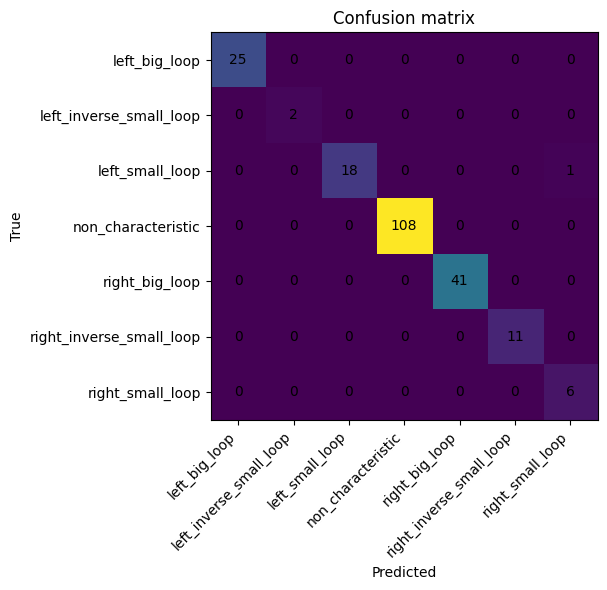

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# y_true = y_test
# y_pred = model.predict(X_test)

y_pred = clf_logreg.predict(Xt)  # model can be SVC/LinearSVC/Pipeline

labels_order = sorted(np.unique(np.concatenate([np.asarray(yt), np.asarray(y_pred)])))
cm = confusion_matrix(yt, y_pred, labels=labels_order)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(labels_order)), labels_order, rotation=45, ha="right")
plt.yticks(range(len(labels_order)), labels_order)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()



In [73]:
# ============================================================
# Trajectory GUI (reads trial_predictions.csv)
# - Session dropdown
# - Pred-label filter dropdown
# - Trial slider (shows only trials matching filter)
# - Plots trajectory over arena background (first video frame)
#
# Requires in memory:
#   aligned_sessions_with_rois : dict[session_id] -> DataFrame (has beh_vid_path, ear_mid_x/y, beh_frame_idx)
#   trials_by_session          : dict[session_id] -> list[(start_frame, end_frame)]
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import cv2

# ---- config ----
PRED_CSV = "logreg_trial_predictions.csv"

FRAME_COL = "beh_frame_idx"
X_COL = "ear_mid_x"
Y_COL = "ear_mid_y"
VIDEO_COL = "beh_vid_path"

ARENA_ALPHA = 0.6
INVERT_Y = True

# ---- load predictions ----
pred_df = pd.read_csv(PRED_CSV)
pred_df["session_id"] = pred_df["session_id"].astype(str)
pred_df["trial_idx"] = pred_df["trial_idx"].astype(int)
pred_df["pred_label"] = pred_df["pred_label"].astype(str)
if "pred_conf" not in pred_df.columns:
    pred_df["pred_conf"] = np.nan
else:
    pred_df["pred_conf"] = pd.to_numeric(pred_df["pred_conf"], errors="coerce")

pred_map = {(r.session_id, int(r.trial_idx)): (r.pred_label, float(r.pred_conf))
            for r in pred_df.itertuples(index=False)}

# ---- sessions available ----
sessions = sorted(set(pred_df["session_id"]) & set(aligned_sessions_with_rois.keys()) & set(trials_by_session.keys()))
if not sessions:
    raise ValueError("No overlap between pred_df sessions and your aligned_sessions_with_rois / trials_by_session keys.")

# ---- arena cache ----
arena_cache = {}

def get_arena_frame(session_id: str):
    if session_id in arena_cache:
        return arena_cache[session_id]

    df = aligned_sessions_with_rois[session_id]
    if VIDEO_COL not in df.columns:
        arena_cache[session_id] = None
        return None

    video_path = df[VIDEO_COL].iloc[0]
    cap = cv2.VideoCapture(str(video_path))
    ok, frame = cap.read()
    cap.release()

    if not ok or frame is None:
        arena_cache[session_id] = None
        return None

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    arena_cache[session_id] = frame
    return frame

# ---- trial slice ----
def get_trial_slice(session_id: str, trial_idx: int):
    s, e = trials_by_session[session_id][trial_idx]
    df = aligned_sessions_with_rois[session_id]
    df_trial = df[(df[FRAME_COL] >= int(s)) & (df[FRAME_COL] <= int(e))].copy()
    return df_trial, int(s), int(e)

# ---- plotting ----
def plot_trial(session_id: str, trial_idx: int):
    df_trial, s, e = get_trial_slice(session_id, trial_idx)

    x = df_trial[X_COL].to_numpy(dtype=float)
    y = df_trial[Y_COL].to_numpy(dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    pl, pc = pred_map.get((session_id, int(trial_idx)), ("(none)", np.nan))
    pred_txt = f"{pl}" + (f" (conf={pc:.2f})" if np.isfinite(pc) else "")

    fig, ax = plt.subplots(figsize=(6, 6))

    arena = get_arena_frame(session_id)
    if arena is not None:
        h, w = arena.shape[:2]
        ax.imshow(arena, extent=[0, w, h, 0], interpolation="nearest", alpha=ARENA_ALPHA)

    if len(x) > 1:
        t = np.linspace(0, 1, len(x))
        ax.scatter(x, y, c=t, s=6)
        ax.plot(x, y, alpha=0.3)
        ax.scatter([x[0]], [y[0]], s=70, marker="o", label="start")
        ax.scatter([x[-1]], [y[-1]], s=70, marker="x", label="end")
    elif len(x) == 1:
        ax.scatter(x, y, s=40)
    else:
        ax.text(0.5, 0.5, "No finite x/y in slice", ha="center", va="center", transform=ax.transAxes)

    ax.set_title(f"{session_id} | trial {trial_idx} | frames {s}-{e}\nPRED: {pred_txt}")
    ax.set_aspect("equal", adjustable="box")
    if INVERT_Y:
        ax.invert_yaxis()
    ax.grid(True)
    ax.legend(loc="best")
    fig.tight_layout()

    return fig

# ---- filter logic (slider -> subset of trial_idx) ----
pred_labels = ["(all)"] + sorted(pred_df["pred_label"].dropna().unique().tolist())

def visible_trials(session_id: str, label_filter: str):
    n = len(trials_by_session[session_id])
    idxs = list(range(n))
    if label_filter == "(all)":
        return idxs
    out = []
    for ti in idxs:
        p = pred_map.get((session_id, ti))
        if p is not None and p[0] == label_filter:
            out.append(ti)
    return out

# ---- widgets ----
session_dropdown = widgets.Dropdown(options=sessions, value=sessions[0], description="Session:")
pred_filter_dropdown = widgets.Dropdown(options=pred_labels, value="(all)", description="Pred:")
trial_slider = widgets.IntSlider(value=0, min=0, max=0, step=1, description="Trial:", continuous_update=False)

out = widgets.Output()
_visible = []

def sync_slider():
    global _visible
    sid = session_dropdown.value
    lab = pred_filter_dropdown.value
    _visible = visible_trials(sid, lab)
    if not _visible:
        _visible = [0]
    trial_slider.max = len(_visible) - 1
    trial_slider.value = 0

def current_trial_idx():
    return int(_visible[int(trial_slider.value)]) if _visible else int(trial_slider.value)

def refresh(change=None):
    with out:
        clear_output(wait=True)
        fig = plot_trial(session_dropdown.value, current_trial_idx())
        display(fig)
        plt.close(fig)

def on_change(_):
    sync_slider()
    refresh()

session_dropdown.observe(on_change, names="value")
pred_filter_dropdown.observe(on_change, names="value")
trial_slider.observe(lambda change: refresh(), names="value")

display(widgets.HBox([session_dropdown, pred_filter_dropdown, trial_slider]), out)
sync_slider()
refresh()

Output()

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

Xt, Xv, yt, yv = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=0
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    n_jobs=-1
)

model.fit(Xt, yt)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Baseline accuracy: 0.7962962962962963
Baseline balanced accuracy: 0.8179012345679012
T: 50
F: 5
n_ts: 250
n_scalar: 14
ts_cols order: ['ear_mid_x', 'ear_mid_y', 'head_dir_rad', 'dist_to_arena_center_px', 'ang_vel_rad_s']
                     group  baseline_accuracy  permuted_accuracy  \
0                ear_mid_y           0.796296           0.562593   
1  dist_to_arena_center_px           0.796296           0.661852   
2                ear_mid_x           0.796296           0.658889   
3          scalar_features           0.796296           0.726667   
4             head_dir_rad           0.796296           0.785926   
5            ang_vel_rad_s           0.796296           0.827037   

   accuracy_drop  baseline_balanced_accuracy  permuted_balanced_accuracy  \
0       0.233704                    0.817901                    0.485653   
1       0.134444                    0.817901                    0.552758   
2       0.137407                    0.817901                    0.634247  

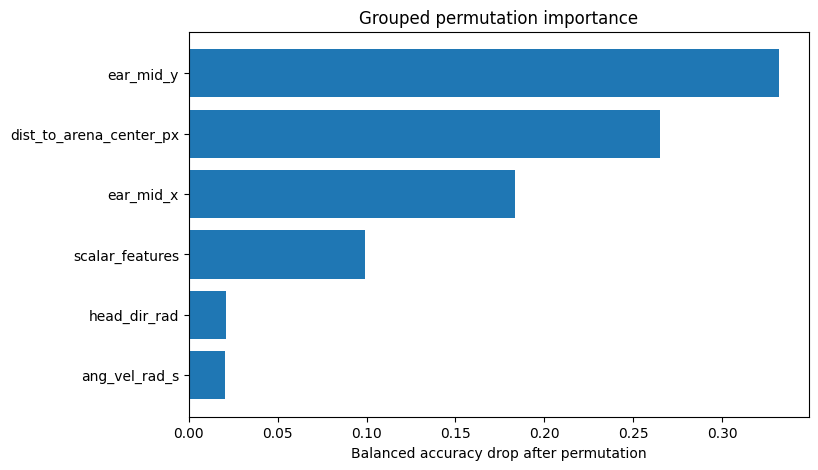

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# Train / validation split
# ------------------------------------------------------------

Xt, Xv, yt, yv = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=0
)

# ------------------------------------------------------------
# Fit model
# ------------------------------------------------------------

model = LogisticRegression(
    max_iter=5000,
    random_state=0
)

model.fit(Xt, yt)

# ------------------------------------------------------------
# Baseline performance
# ------------------------------------------------------------

yv_pred = model.predict(Xv)

baseline_acc = accuracy_score(yv, yv_pred)
baseline_bal_acc = balanced_accuracy_score(yv, yv_pred)

print("Baseline accuracy:", baseline_acc)
print("Baseline balanced accuracy:", baseline_bal_acc)

# ------------------------------------------------------------
# Define grouped feature blocks
# ------------------------------------------------------------

T = feat_engine.T
F = len(feat_engine.ts_cols)
n_ts = T * F
n_total = X.shape[1]
n_scalar = n_total - n_ts

print("T:", T)
print("F:", F)
print("n_ts:", n_ts)
print("n_scalar:", n_scalar)

# Order of channels follows feat_engine.ts_cols exactly
print("ts_cols order:", feat_engine.ts_cols)

groups = {}

for j, col_name in enumerate(feat_engine.ts_cols):
    groups[col_name] = np.arange(j, n_ts, F)

groups["scalar_features"] = np.arange(n_ts, n_total)

# ------------------------------------------------------------
# Group permutation importance
# ------------------------------------------------------------

rng = np.random.default_rng(0)
n_repeats = 50

rows = []

for group_name, cols in groups.items():

    acc_scores = []
    bal_acc_scores = []

    for _ in range(n_repeats):
        Xv_perm = Xv.copy()

        perm_idx = rng.permutation(Xv.shape[0])
        Xv_perm[:, cols] = Xv_perm[perm_idx][:, cols]

        yv_perm_pred = model.predict(Xv_perm)

        acc_scores.append(accuracy_score(yv, yv_perm_pred))
        bal_acc_scores.append(balanced_accuracy_score(yv, yv_perm_pred))

    mean_acc = np.mean(acc_scores)
    mean_bal_acc = np.mean(bal_acc_scores)

    rows.append({
        "group": group_name,
        "baseline_accuracy": baseline_acc,
        "permuted_accuracy": mean_acc,
        "accuracy_drop": baseline_acc - mean_acc,
        "baseline_balanced_accuracy": baseline_bal_acc,
        "permuted_balanced_accuracy": mean_bal_acc,
        "balanced_accuracy_drop": baseline_bal_acc - mean_bal_acc,
    })

group_importance_df = pd.DataFrame(rows).sort_values(
    "balanced_accuracy_drop",
    ascending=False
).reset_index(drop=True)

print(group_importance_df)

import matplotlib.pyplot as plt

plot_df = group_importance_df.sort_values("balanced_accuracy_drop", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["group"], plot_df["balanced_accuracy_drop"])
plt.xlabel("Balanced accuracy drop after permutation")
plt.title("Grouped permutation importance")
plt.show()